In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
import glob as gl

# For the extra plotting functionality (see latter code blocks)

import seaborn as sn
import scipy as sp
import statsmodels.api as sm
from sklearn import linear_model


# Reading the permafrost files from CEDA archive

In [3]:
target_path = r'/neodc/esacci/permafrost/data/permafrost_extent/L4/area4/pp/v04.0'

# Verifies the file path actually exists:
# If no -> prints an error message
# If yes -> uses the glob module to return all files in the target directory that have the .nc extension

if not os.path.exists(target_path):
    print(f"Error: The path {target_path} does not exist on this machine.")
    
else:
	permafrost_extent_files = gl.glob(target_path + '/*.nc')


      
# Reads all the files in at once and conctenates them along the time dimension (defaults to whichever
# dimension differs), thus allowing for ease of plotting multi-year PFR plots.

permafrost_extent = xr.open_mfdataset(permafrost_extent_files)    
      
# Selects the permafrost fraction values for the first dataset (1997), then slices the data to only
# include values of latitude of 50 degrees and above (arctic region).

permafrost_fraction_1997 = permafrost_extent['PFR'].isel(time = 0)

permafrost_fraction_1997 = permafrost_fraction_1997.sel(lat = slice(50.0, 90.0))

#permafrost_fraction_1997

permafrost_fraction = permafrost_extent['PFR'].sel(lat = slice(50.0, 90.0))

permafrost_fraction

/tmp/ipykernel_4182238/2855850074.py:18: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  permafrost_extent = xr.open_mfdataset(permafrost_extent_files)


<xarray.DataArray 'PFR' (time: 25, lat: 3500, lon: 36000)> Size: 13GB
dask.array<getitem, shape=(25, 3500, 36000), dtype=float32, chunksize=(1, 1000, 1000), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 200B 1997-01-01 1998-01-01 ... 2021-01-01
  * lat      (lat) float32 14kB 50.01 50.01 50.03 50.03 ... 84.97 84.98 84.99
  * lon      (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Attributes:
    standard_name:  permafrost_area_fraction
    grid_mapping:   spatial_ref
    units:          percent
    conversion:     no
    valid_min:      0
    valid_max:      100

# Creating a colourmap plot of permafrost fraction

Text(0.5, 1.0, 'Permafrost Fraction 1997')

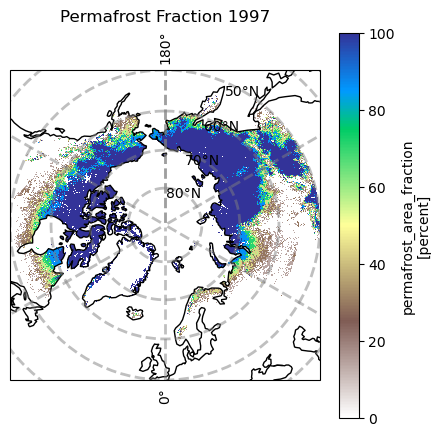

In [4]:
fig = plt.figure(figsize=(5, 5))             
ax = plt.axes(projection=ccrs.NorthPolarStereo())
permafrost_fraction_1997.plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'terrain_r')
ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
ax.coastlines()                                   
ax.set_title('Permafrost Fraction 1997')

# Creating an annual mean plot of the permafrost fraction

Each of these methods are useful in different contexts (e.g. what you're plotting and what your aims are). 

Note: The y-intercepts calculated here are massive, this is likely due to the fact that the x-axis starts at 1997, and so it is extending this line back a long way (to an intercept at year 0).

### Using Numpy polyfit

Text(0, 0.5, 'Average Permafrost Fraction (%)')

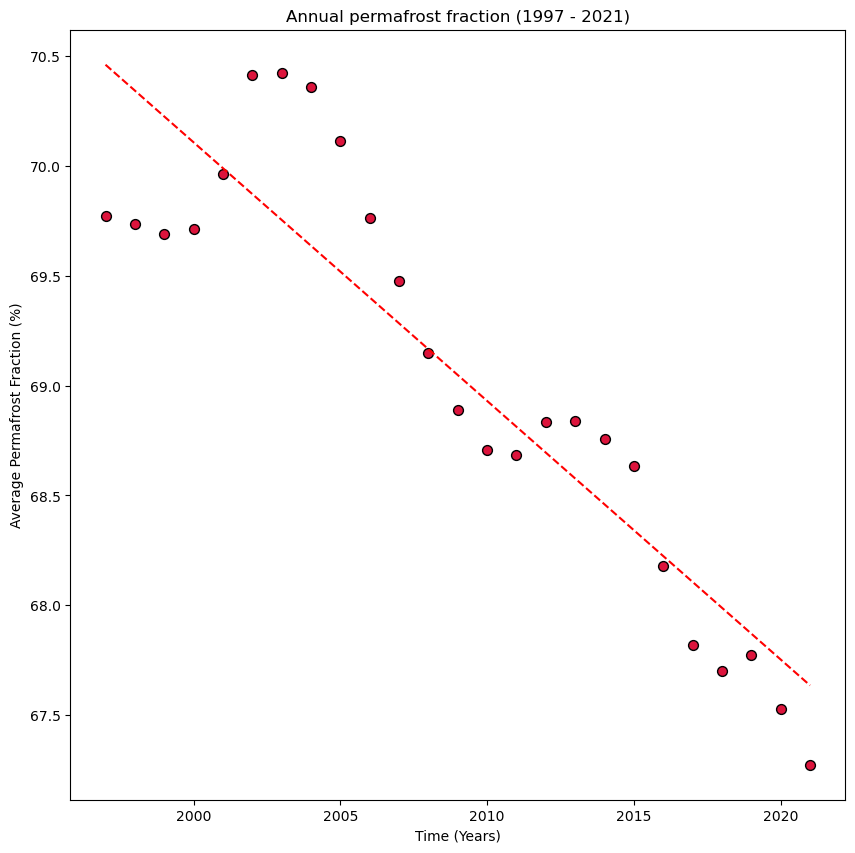

In [ ]:
# Calculates the mean of the permafrost fraction for each year

permafrost_fraction_annual = permafrost_fraction.mean(('lon', 'lat'))

# Extracts integer years from the original time units of the array

time = permafrost_fraction["time"].dt.year.values


# Creates the 1D regression line fit

coef = np.polyfit(time, permafrost_fraction_annual, 1)          
fn = np.poly1d(coef)                                            


fig = plt.figure(figsize=(10,10)) 
plt.scatter(time, permafrost_fraction_annual, c="crimson", edgecolor="black", s=50)
plt.plot(time, fn(time), '--r')
plt.title('Annual permafrost fraction (1997 - 2021)')
plt.xlabel('Time (Years)')
plt.ylabel('Average Permafrost Fraction (%)')


### Using Seaborn regplot

Text(0.5, 1.0, 'Annual permafrost fraction (1997 - 2021)')

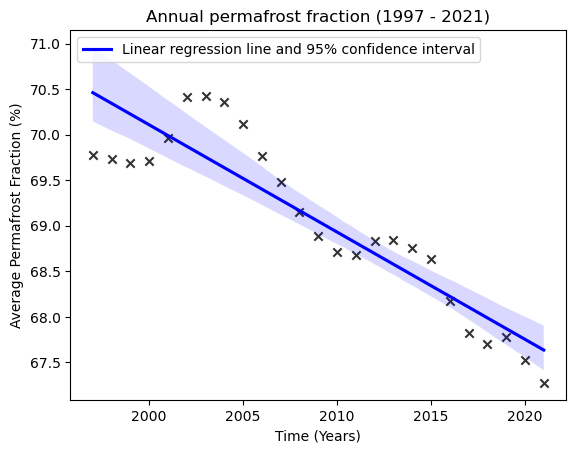

In [17]:
sn.regplot(x = time, y = permafrost_fraction_annual, data = permafrost_fraction_annual, marker = 'x', color = 'black', line_kws={'label': 'Linear regression line and 95% confidence interval', 'color': 'b'})
plt.xlabel('Time (Years)')
plt.ylabel('Average Permafrost Fraction (%)')
plt.legend(loc="upper left")
plt.title('Annual permafrost fraction (1997 - 2021)')

### Using statsmodels 

This block includes some useful statistical results, as well as some diagnostic plotting functions to check the accuracy of a fitted model

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     109.3
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           3.30e-10
Time:                        14:56:30   Log-Likelihood:                -11.906
No. Observations:                  25   AIC:                             27.81
Df Residuals:                      23   BIC:                             30.25
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        305.5933     22.631     13.503      0.0

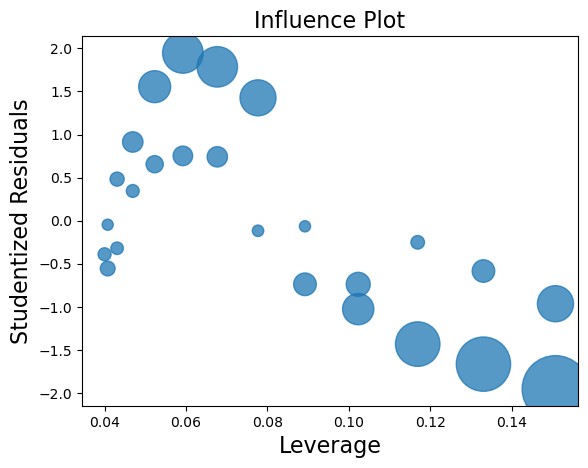

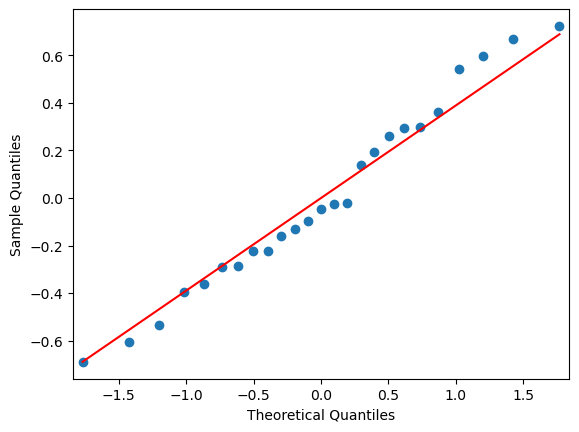

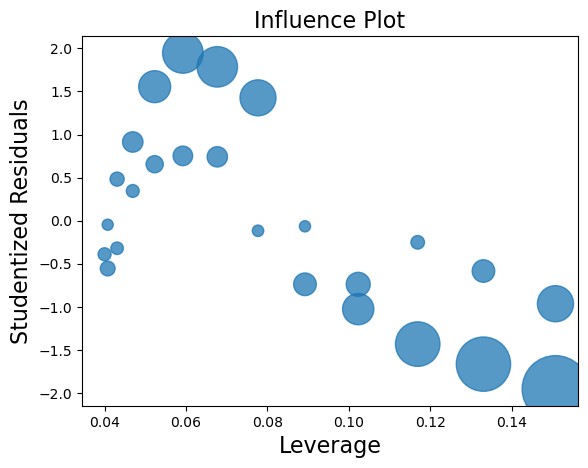

In [ ]:
x = sm.add_constant(time)                                     # Adds an intercept term to the simple linear regression formula
model = sm.OLS(permafrost_fraction_annual.values, x).fit()    # Needed to convert xarray to a numpy array (using .values) for OLS fitting to work
print(model.summary())                                        # Prints a nicely formatted table with an extensive list of regression statistics

model.params                             # Gives the intercept and gradient respectively

model_residuals = model.resid            # Stores the residuals (differences between the model and the actual data)

# Checks the residuals against a normal distribution (after standardising, which is highly reccomended) and plots, the closer to the line the points are, the more reliable the model

sm.qqplot(model_residuals, line = 's')   

# Displays which data points influence the regression line the most (larger bubbles = greater influence)
# In this case, the lowest residuals (model underestimates) have the most leverage on the regression line, thus the most influence

sm.graphics.influence_plot(model)


                                         


### Using SciPy

Text(0, 0.5, 'Average Permafrost Fraction (%)')

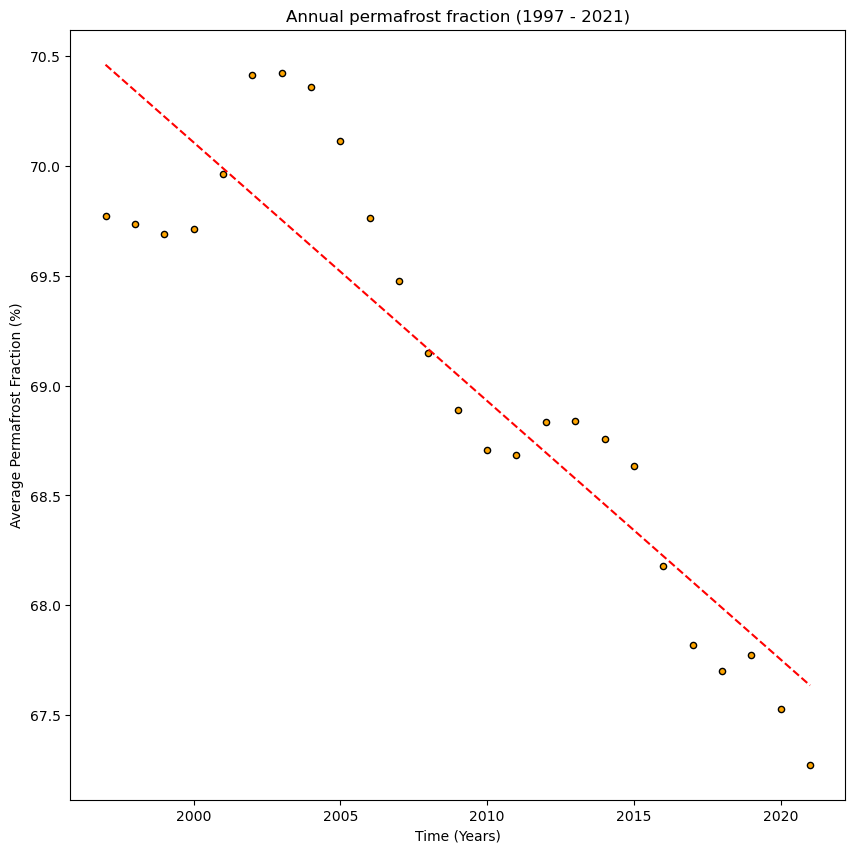

In [44]:
# Calculates regression values (slope and intercept) and statistics

regression_results = sp.stats.linregress(time, permafrost_fraction_annual)
regression_results

# Creates a plot by accessing the required regression values to plot the line (y =) mx + c.

fig = plt.figure(figsize=(10,10)) 
plt.scatter(time, permafrost_fraction_annual, c="orange", edgecolor="black", s=20)
plt.plot(time, regression_results.slope*time + regression_results.intercept, '--r')
plt.title('Annual permafrost fraction (1997 - 2021)')
plt.xlabel('Time (Years)')
plt.ylabel('Average Permafrost Fraction (%)')

### Using scikit-learn

Uses the least squares method to fit a regression line, returns parameters in a nicely formatted table. 

Can also be used to predict new values (extrapolation).

The slope and intercept are as follows: Slope = -0.11774273799015922 Intercept = 305.5932718893197
0.8260900544598674
[71.28522329 67.04648472]


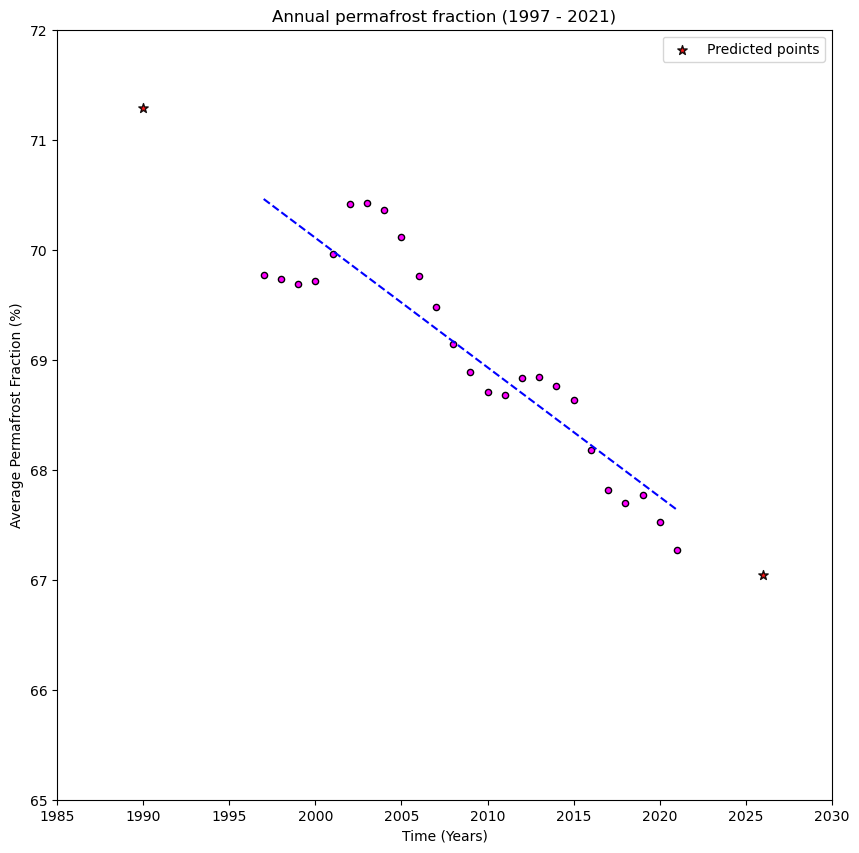

In [ ]:
# Fits a linear regression model to the data and produces a table, also extracts key statistical values

linmodel = linear_model.LinearRegression() 
linmodel.fit(time.reshape(-1, 1), permafrost_fraction_annual)

(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print('The slope and intercept are as follows: Slope =', slope, 'Intercept =', intercept)

r_squared = linmodel.score(time.reshape(-1, 1), permafrost_fraction_annual)
print(r_squared)

# Predicts new  PFR values for 1990 and 2026 based on the fitted model

new_years = np.array([1990, 2026])

predicted_PFR = linmodel.predict(new_years.reshape(-1, 1))

print(predicted_PFR)

fig = plt.figure(figsize=(10,10)) 
plt.scatter(time, permafrost_fraction_annual, c="magenta", edgecolor="black", s=20)
plt.plot(time, slope*time + intercept, '--b')
plt.title('Annual permafrost fraction (1997 - 2021)')
plt.xlabel('Time (Years)')
plt.ylabel('Average Permafrost Fraction (%)')
plt.xlim(1985, 2030)
plt.ylim(65, 72)

plt.scatter(new_years, predicted_PFR, c='red', s=50, marker='*', alpha=0.9, label='Predicted points', edgecolors='black')     # Adding in the additional points predicted with sci-kit learn
plt.legend()
